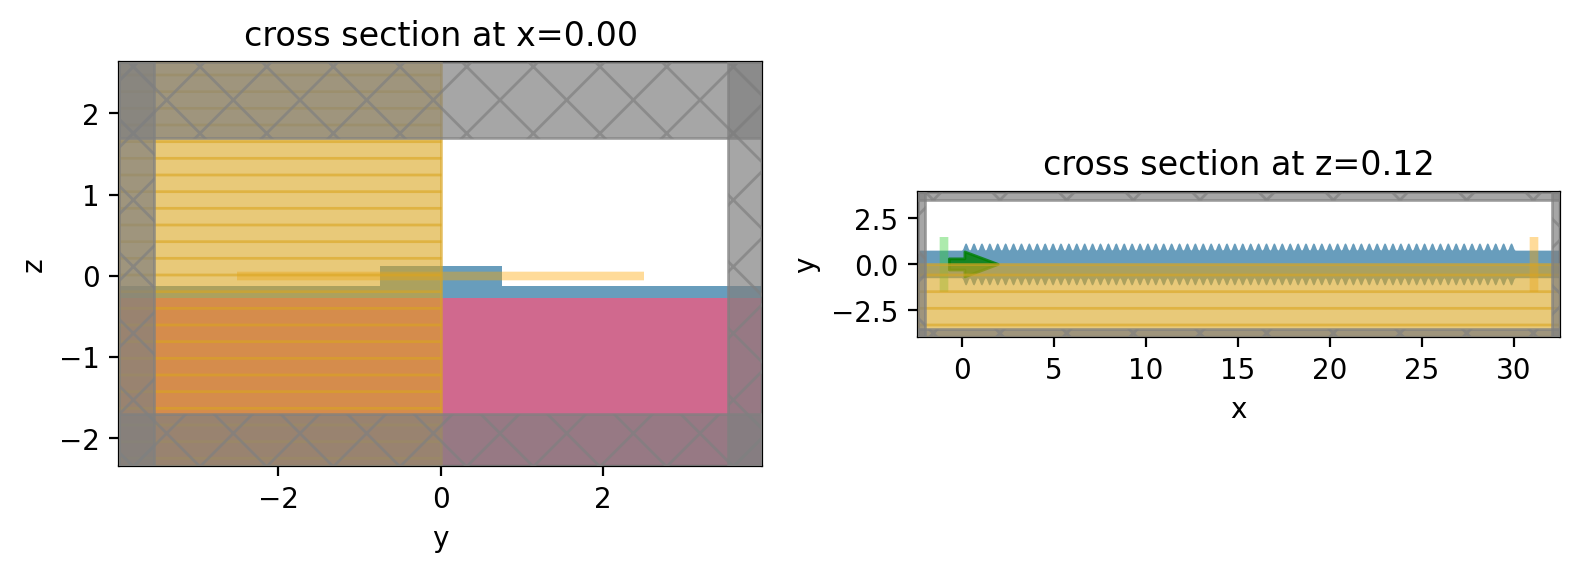

In [126]:
# basic imports
import numpy as np
import matplotlib.pylab as plt

# Tidy3D imports
import tidy3d as td
from tidy3d.plugins.mode import ModeSolver
from tidy3d.plugins.mode.web import run as run_mode_solver


# materials
eff_inf = 100
n_sio2 = 1.444  # silicon oxide refractive index at 1550 nm
sio2 = td.Medium(permittivity=n_sio2**2)
air = td.Medium(permittivity=1)
ln_no_coeffs = [(2.6734, 0.01764), (1.2290, 0.05914), (12.614, 474.60)]
ln_ne_coeffs = [(2.6734, 0.01764),  (1.2290, 0.05914),  (12.614, 474.60)]
ln_no= td.Sellmeier(coeffs=ln_no_coeffs)
ln_ne= td.Sellmeier(coeffs=ln_ne_coeffs)
ln = td.AnisotropicMedium(xx=ln_ne, yy=ln_no, zz=ln_no)

## source
wavelength0 = 1.55
freq0 = td.C_0 / wavelength0
fwidth = freq0 / 40.0
run_time = 5.0e-12
wavelength_min = td.C_0 / (freq0 + fwidth)


# 파라미터 설정
sidewall_angle=(0)*np.pi/180
Hc=0.250
Hs=0.150

      # 전체 길이
mnum=70
w_g= 0.2
w_wg= 1.5
num_points = 500  # 샘플링할 x 값의 개수
period = 0.43    # 사인파의 주기 (파장)
phase = -np.pi/2    # 사인파의 위상
l=period*mnum
x = np.linspace(0, l, num_points)  # x 축 좌표 생성
amplitude = w_g   # 사인파 진폭

buffer_length=2
size_x=buffer_length*2+l
size_y=1.55*1.2+w_g+w_wg*2+2


# 사인파 형태로 너비를 정의하는 함수
def sinusoidal_width(x, A=0.5, wavelength=5, phase=0,off_set=1):
    return A * (np.sin(2 * np.pi * x / wavelength + phase)+1)+off_set

# 구조의 윗부분과 아랫부분의 y 좌표를 정의
y_upper = sinusoidal_width(x, amplitude, wavelength=period, phase=phase,off_set=w_wg/2)
y_lower = -y_upper  # 대칭적인 하단 부분

# 윗부분과 아랫부분의 좌표를 결합하여 다각형 형태의 꼭짓점 정의
vertices1 =[(0,-w_wg/2),(-eff_inf,-w_wg/2),(-eff_inf,w_wg/2),(0,w_wg/2)]
vertices2 =[(l,w_wg/2),(eff_inf,w_wg/2),(eff_inf,-w_wg/2),(l,-w_wg/2)]
vertices = np.column_stack((x, y_upper))  # 윗부분의 꼭짓점
vertices =np.vstack([vertices,vertices2])
vertices = np.vstack([vertices, np.column_stack((x[::-1], y_lower[::-1]))])  # 아랫부분 꼭짓점 결합
vertices =np.vstack([vertices,vertices1])

LN_grating = td.Structure(
    geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"), medium=ln
)



# ln slab
ln_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -Hc/2-Hs),
        rmax=(eff_inf, eff_inf, -Hc/2),
    ),
    medium=ln,
)


# SiO2 BOX layer.
sio2_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -eff_inf),
        rmax=(eff_inf, eff_inf, -Hc/2-Hs),
    ),
    medium=sio2,
)


# boundary conditions - Bloch boundaries are used to emulate an infinitely long grating
boundary_spec = td.BoundarySpec(
    # x=td.Boundary.bloch(bloch_vec=num_periods/2),
    x=td.Boundary.pml(),
    y=td.Boundary.pml(),
    z=td.Boundary.pml(),
)

# grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20)

# mode source for waveguide 
source1_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth, amplitude=1)
mode_src1 = td.ModeSource(
    center=[-buffer_length/2, 0, 0],
    size=[0, w_wg * 2, 3],
    mode_index=0,
    direction="+",
    source_time=source1_time,
    mode_spec=td.ModeSpec(),
)

# create monitors
monitor_xy = td.FieldMonitor(
    center=[l/2, 0, 0],
    size=[l+2*buffer_length, 2 * wavelength0 + w_wg + 2 * w_g, 0],
    freqs=[freq0],
    name="fields_xy",
)

freqs = np.linspace(freq0 - 2 * fwidth, freq0 + 2 * fwidth, 200)
monitor_flux = td.FluxMonitor(
    center=[l+buffer_length/2, 0, 0],
    size=[0, w_wg * 2, 3],
    freqs=freqs,
    name="flux",
)

# list of all structures
structures = (
    [LN_grating,ln_substrate,sio2_substrate]
)
# list of all sources
sources = [mode_src1]
# list of all monitors
monitors = [monitor_xy, monitor_flux]

# create the simulation
sim = td.Simulation(

    center=(l/2, 0, 0),
    size=(size_x, size_y, Hc+Hs+3),
    grid_spec=grid_spec,
    structures=structures,
    sources=sources,
    monitors=monitors,
    run_time=run_time,
    boundary_spec=boundary_spec,
    symmetry=(0, -1, 0),
)

# plot the simulation domain
f, (ax1, ax3) = plt.subplots(1, 2, tight_layout=True, figsize=(8, 4))
sim.plot(x=0, ax=ax1)
sim.plot(z=Hc/ 2, ax=ax3)
#ax3.set_xlim(0, 20 * period)
plt.show()

## Run Simulation

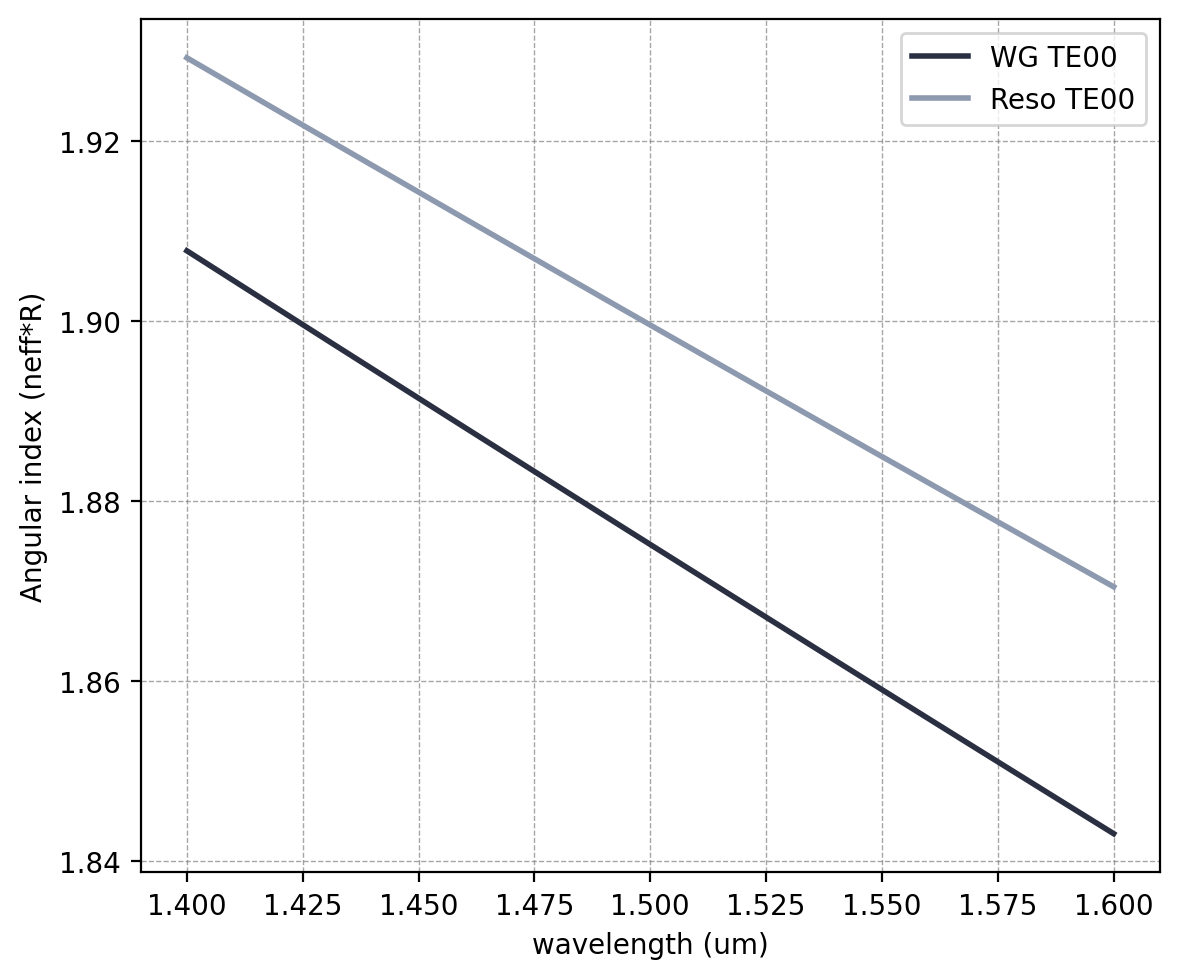

[0.785824   0.7941718  0.80229115 0.810183   0.8178576  0.8252999
 0.83251077 0.83950716 0.8462888  0.85283893 0.85917914 0.86530286
 0.87121826 0.87693244 0.8824323  0.8877441  0.8928584  0.8977736
 0.9025137  0.90705615]


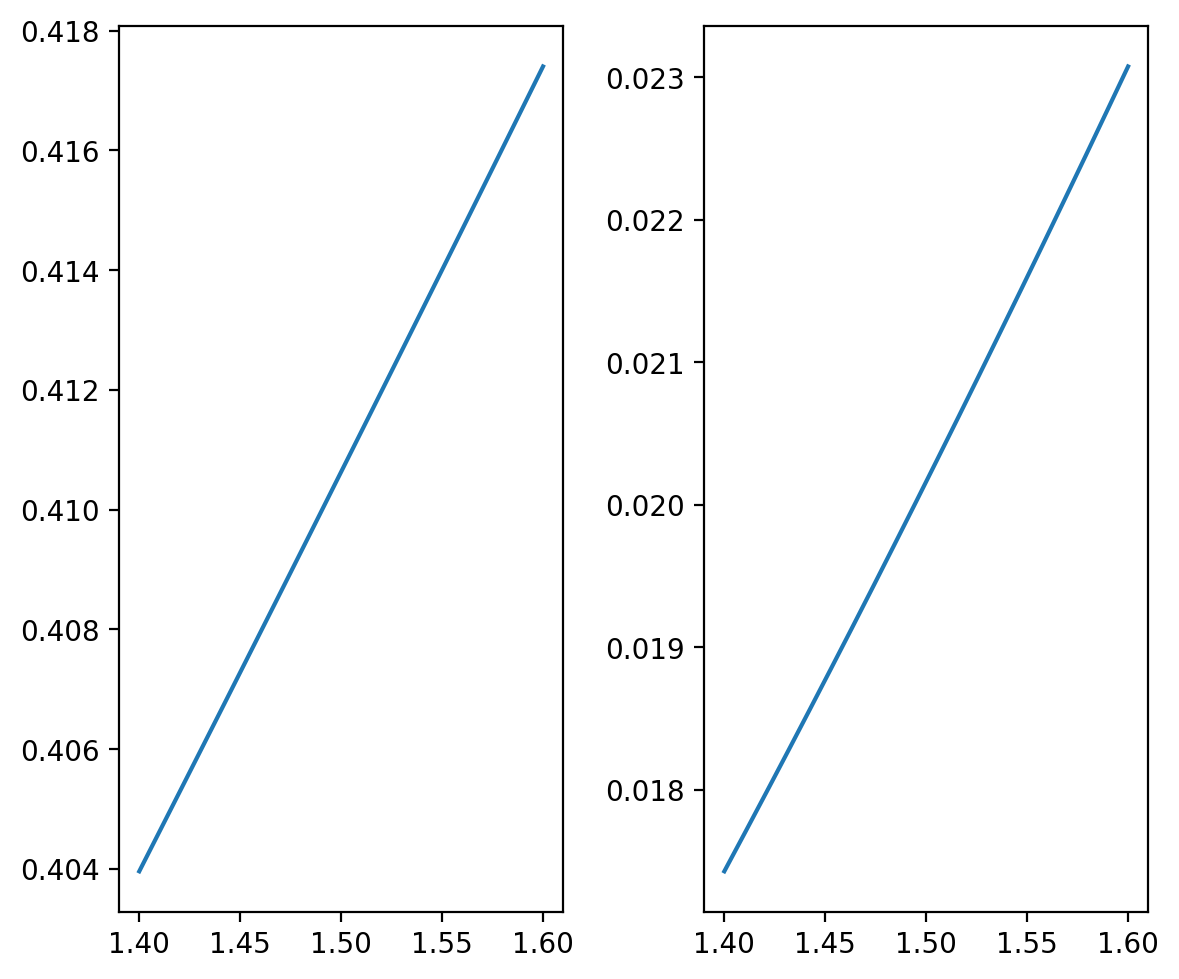

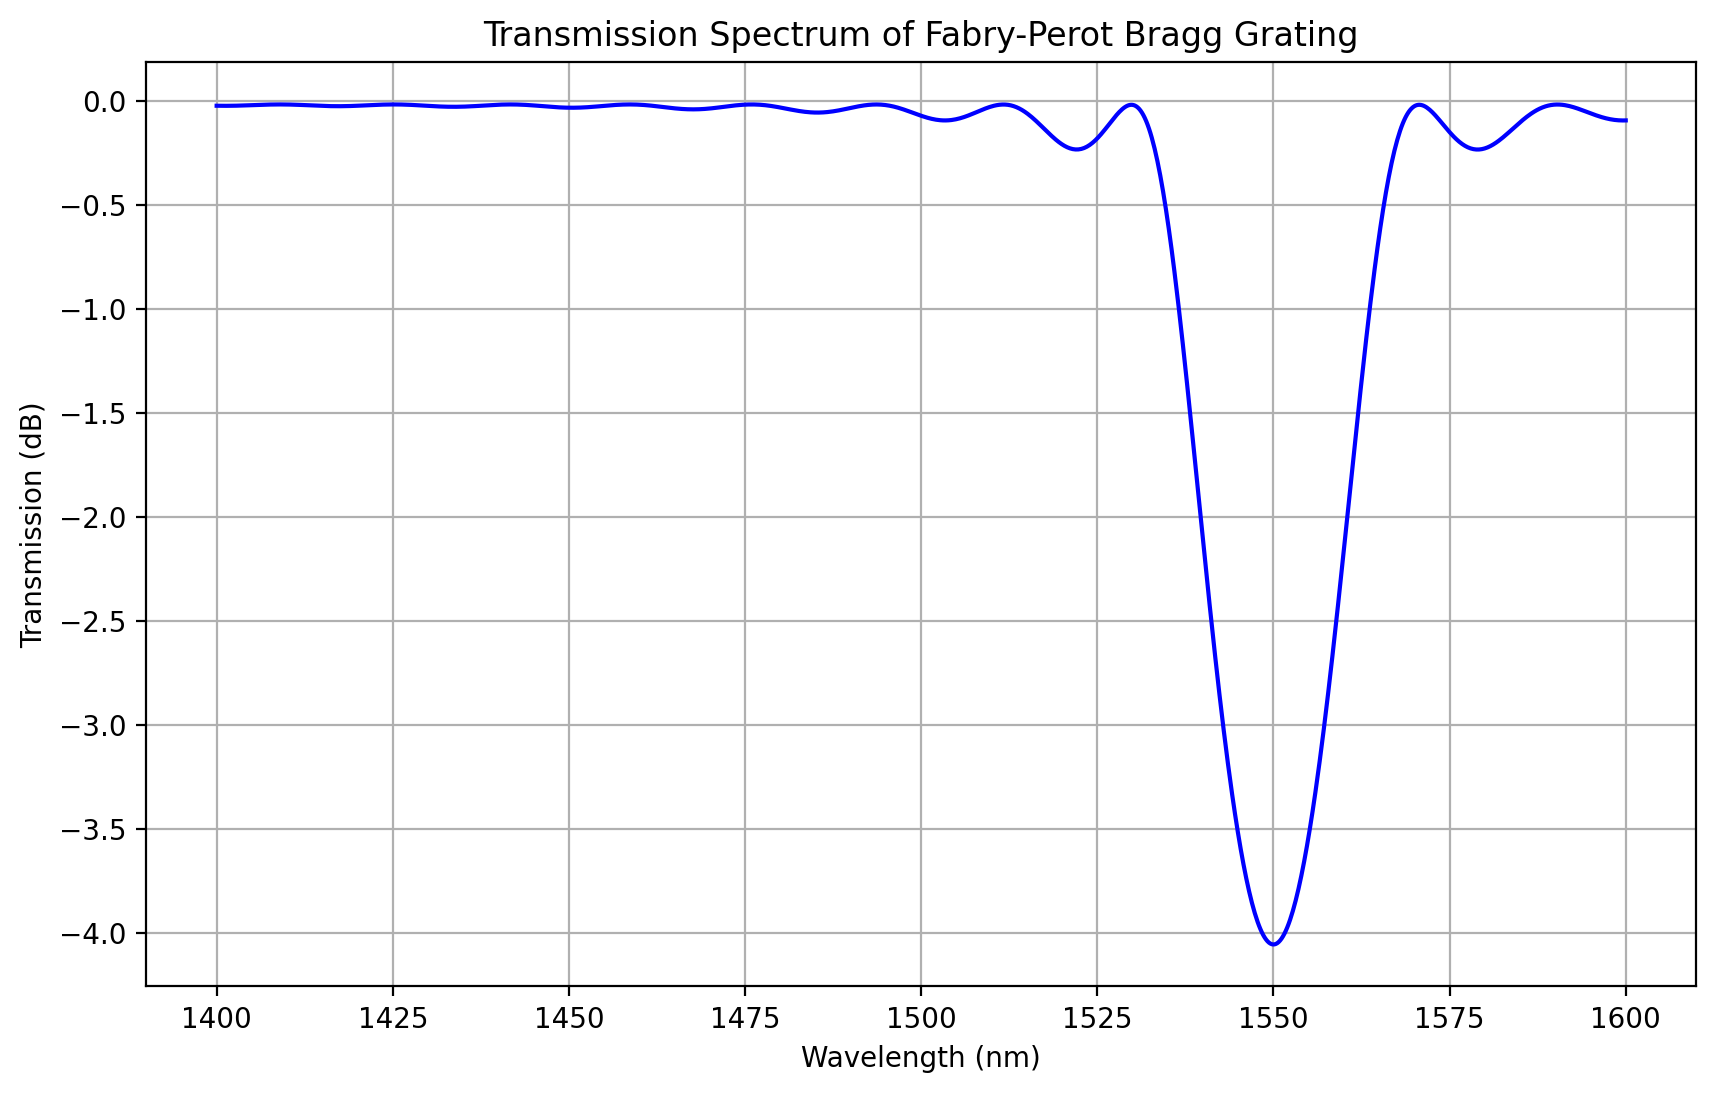

In [133]:
wl_num=20
wl_range = np.linspace(1.4, 1.6, wl_num)
wl_c=1.55
freqs = td.C_0 / wl_range
# Modal source plane
source_plane1 = td.Box(center=[0, 0, 0], size=[0, 3, 2])
source_plane2 = td.Box(center=[period/2, 0, 0], size=[0, 3, 2])

num_modes = 1
# NB: negative radius since the plane position is at y=-radius
mode_spec = td.ModeSpec(num_modes=num_modes)
ms1 = ModeSolver(simulation=sim, plane=source_plane1, freqs=freqs, mode_spec=mode_spec)

modes_wg = ms1.solve()

mode_spec = td.ModeSpec(num_modes=num_modes)
ms2 = ModeSolver(simulation=sim, plane=source_plane2, freqs=freqs, mode_spec=mode_spec)

modes_reso = ms2.solve()


#mode_data = run_mode_solver(mode_solver)
# Plot the mode effective index.
n1 = modes_wg.n_eff.values.squeeze()
n2 = modes_reso.n_eff.values.squeeze()
fig, ax = plt.subplots(1, 1, figsize=(6, 5), tight_layout=True)
y=[n1,n2]
x=wl_range
%config InlineBackend.figure_format = 'retina'
labels = ["WG TE00", "Reso TE00"]
colors = ["#2B2F42", "#8D99AE", "#EF233C"]
for i, label in enumerate(labels):
    # Line
    ax.plot(x, y[i], label=label, color=colors[i], linewidth=2)

ax.set_xlabel("wavelength (um)")
ax.set_ylabel("Angular index (neff*R)")
ax.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

# 파라미터 설정
lda_set = np.linspace(1400, 1600, 1000) * 1e-9  # 1520nm ~ 1580nm 범위의 파장



fig, ax = plt.subplots(1, 2, figsize=(6, 5), tight_layout=True)
kappa=np.pi/wl_c*(n2-n1)
lg=wl_c/(n1+n2)
mnum = 80  # 그레이팅 주기 수
del_lda=wl_c**2*kappa/np.pi/n1
Ref=np.tanh(kappa*lg*mnum)**2
print(Ref)
ax[0].plot(wl_range,lg)
ax[1].plot(wl_range,del_lda)



n1 = n1[int(wl_num/2)]
n2 = n2[int(wl_num/2)]
ldac = 1550e-9  # 중심 파장
lg = ldac / (n1 + n2)  # 그레이팅 주기
Length = 50e-6  # 그레이팅 길이

# 전송 스펙트럼 저장 배열 초기화
T_set = np.zeros(len(lda_set))

# 전송 스펙트럼 계산
for i, lda in enumerate(lda_set):
    # 감쇠 계수 계산
    alpha = 10**(0.3/10) / 0.01
    n_i = lda * alpha / 4 / np.pi

    # 각 층의 파수 벡터
    k1z = 2 * np.pi * (n1 - 1j * n_i) / lda
    k2z = 2 * np.pi * (n2 - 1j * n_i) / lda
    phi = 2 * np.pi * Length * n1 / lda

    # 전송 행렬 계산
    Tg1 = np.array([[(k1z + k2z) * np.exp(1j * k2z * lg / 2), (k1z - k2z) * np.exp(-1j * k2z * lg / 2)],
                    [(k1z - k2z) * np.exp(1j * k2z * lg / 2), (k1z + k2z) * np.exp(-1j * k2z * lg / 2)]]) / (2 * k1z)
    Tg2 = np.array([[(k1z + k2z) * np.exp(1j * k1z * lg / 2), (-k1z + k2z) * np.exp(-1j * k1z * lg / 2)],
                    [(-k1z + k2z) * np.exp(1j * k1z * lg / 2), (k1z + k2z) * np.exp(-1j * k1z * lg / 2)]]) / (2 * k2z)
    Tg = np.dot(Tg1, Tg2)

    R = np.linalg.matrix_power(Tg, mnum)
    
    # 전송 스펙트럼 계산 및 저장
    T_set[i] = 1 / abs(R[0, 0])**2

# 전송 스펙트럼 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(lda_set * 1e9, 10 * np.log10(T_set), 'b-', linewidth=1.5)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission (dB)')
plt.title('Transmission Spectrum of Fabry-Perot Bragg Grating')
plt.grid(True)
plt.show()



In [128]:
# run simulation
import tidy3d.web as web

sim_data = web.run(sim, task_name="bragg", path="data/bragg.hdf5", verbose=True)

02:37:34 KST Created task 'bragg' with task_id                                  
             'fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=61327;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=968717;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\taskId]8;;\]8;id=61327;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\=]8;;\]8;id=727649;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\fdve]8;;\]8;id=61327;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\-a889b646-2c5]8;;\
             ]8;id=61327;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\2-4ad0-a9a1-1d2a01c205c3']8;;\.

/Users/hwanghyeon/pattern/tidy/lib/python3.11/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

02:37:37 KST status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

02:38:09 KST early shutoff detected at 28%, exiting.

             status = postprocess

02:38:10 KST status = success

02:38:11 KST View simulation result at                                          
             ]8;id=475886;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=912466;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\taskId]8;;\]8;id=475886;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\=]8;;\]8;id=534060;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\fdve]8;;\]8;id=475886;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\-a889b646-2c5]8;;\
             ]8;id=475886;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a889b646-2c52-4ad0-a9a1-1d2a01c205c3\2-4ad0-a9a1-1d2a01c205c3']8;;\.

02:38:13 KST loading simulation from data/bragg.hdf5

## Field Plot

The frequency-domain fields are plotted in the `xy` plane cutting through the waveguides. We notice that the grating with aligned corrugation effectively reflects power at the design frequency, while the misalignment in the second grating causes it to be mostly transmissive.

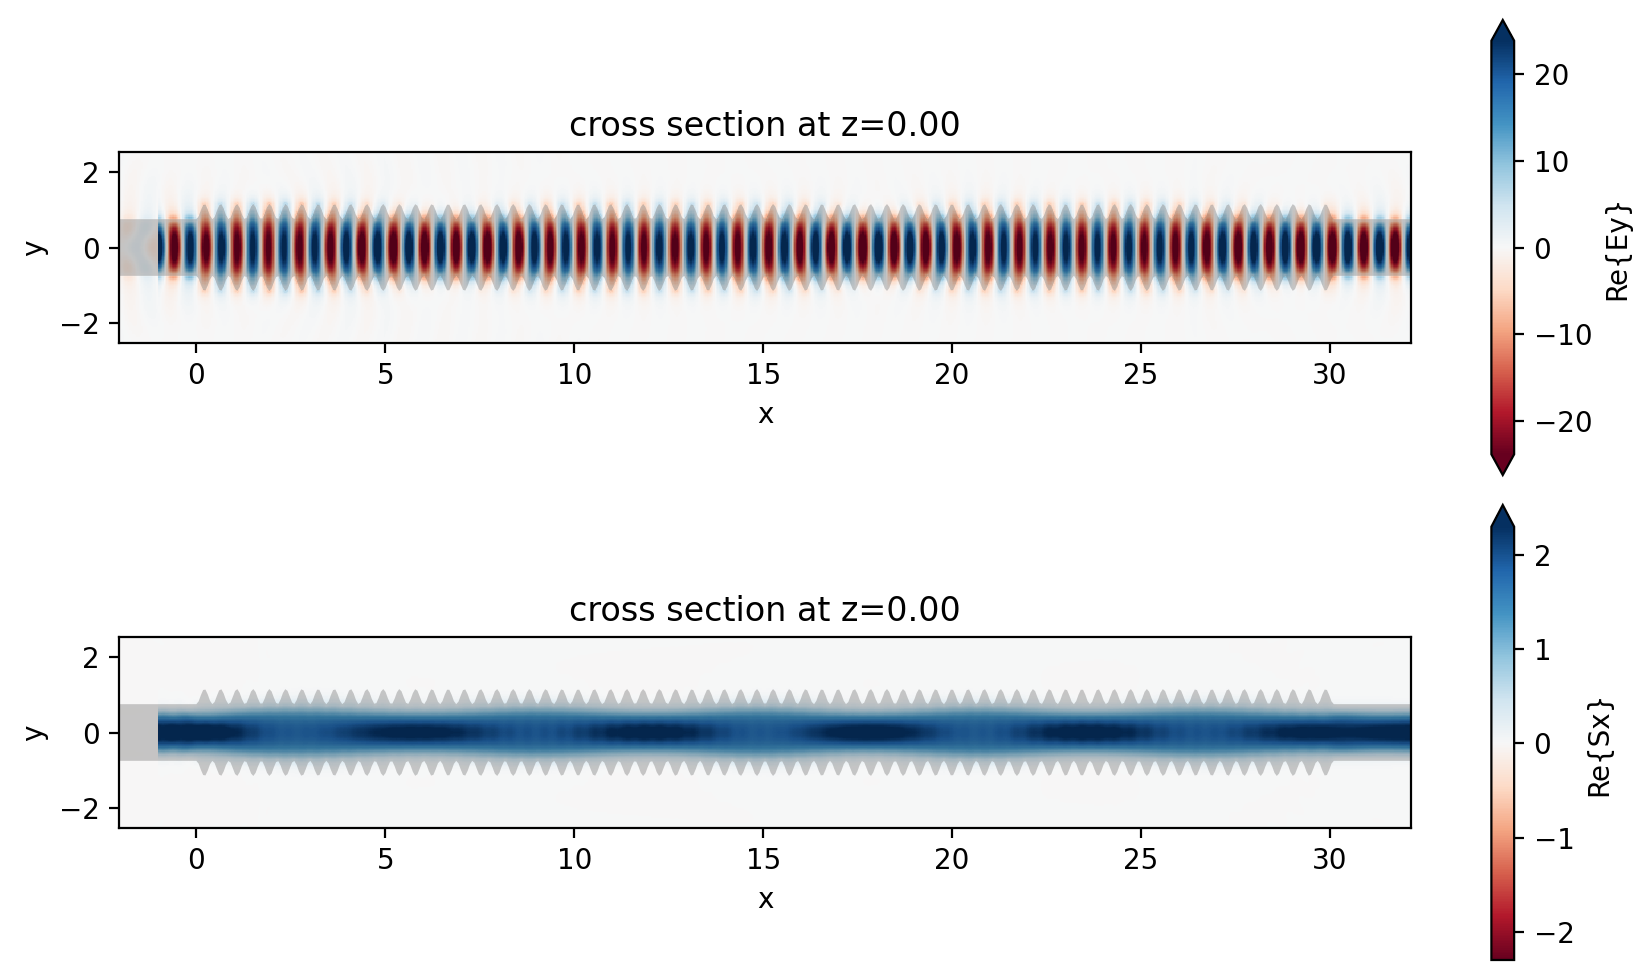

In [135]:
# plot fields on the monitor
fig, ax = plt.subplots(2, 1, tight_layout=True, figsize=(9, 5))
sim_data.plot_field(field_monitor_name="fields_xy", field_name="Ey", val="real", f=freq0, ax=ax[0])
sim_data.plot_field(field_monitor_name="fields_xy", field_name="Sx", val="real", f=freq0, ax=ax[1])
plt.show()

## Transmission and Reflection

The observations made in the field plot above can be confirmed by plotting the flux recorded by the flux monitors as a function of frequency. In the region of the design frequency, indicated by the dashed black line, the drop in flux for the aligned-corrugation grating confirms its reflective property. 

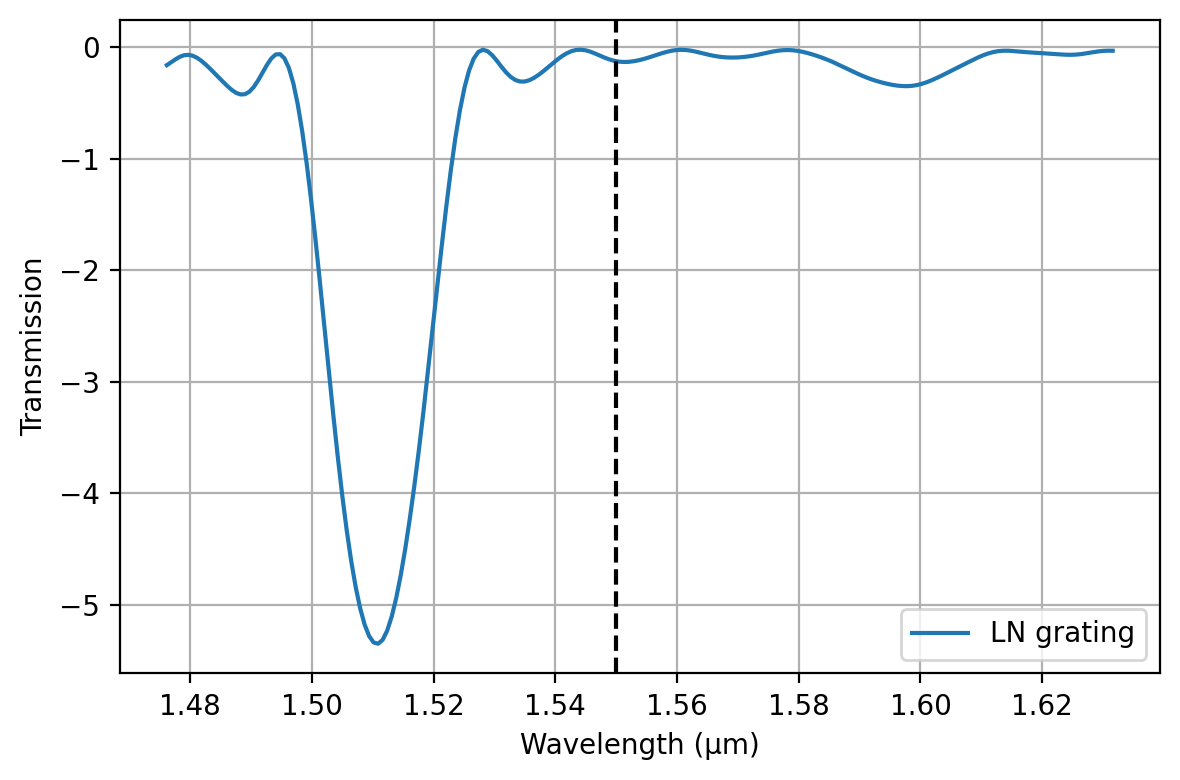

In [130]:
fig, ax = plt.subplots(figsize=(6, 4), tight_layout=True)
freqs = np.linspace(freq0 - 2 * fwidth, freq0 + 2 * fwidth, 200)
# plot transmitted flux for each waveguide
ax.plot(td.C_0 / freqs, 10*np.log10(sim_data["flux"].flux), label="LN grating")



# vertical line at design frequency
ax.axvline(td.C_0 / freq0, ls="--", color="k")

ax.set(xlabel="Wavelength (µm)", ylabel="Transmission")

ax.grid(True)
plt.legend()
plt.show()